<a href="https://colab.research.google.com/github/WeegorMartins/WeegorMartins/blob/main/Silent_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup do ambiente, bibliotecas e identidade visual**

In [2]:
!pip -q install duckdb faker missingno plotly

import warnings
import random
import numpy as np
import pandas as pd
import duckdb
from faker import Faker

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import missingno as msno

from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
Faker.seed(SEED)
fake = Faker("pt_BR")

BRAND = {
    "navy": "#0F172A",
    "slate": "#475569",
    "cyan": "#06B6D4",
    "emerald": "#10B981",
    "amber": "#F59E0B",
    "rose": "#F43F5E",
    "violet": "#8B5CF6",
    "soft": "#E2E8F0"
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.7 MB/s eta 0:00:00


In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def plotly_style(fig, title, height=520):
    fig.update_layout(
        template="plotly_white",
        title={
            "text": title,
            "x": 0.01,
            "xanchor": "left",
            "font": {"size": 20, "color": BRAND["navy"]}
        },
        font={"family": "Arial", "color": BRAND["navy"]},
        paper_bgcolor="white",
        plot_bgcolor="white",
        legend_title_text="",
        margin=dict(l=40, r=30, t=80, b=40),
        height=height
    )
    fig.update_xaxes(showgrid=False, linecolor=BRAND["soft"])
    fig.update_yaxes(gridcolor=BRAND["soft"], zeroline=False)
    return fig

def table_overview(name, df, duplicate_subset=None):
    duplicates = df.duplicated(subset=duplicate_subset).sum() if duplicate_subset else df.duplicated().sum()
    missing_pct = (df.isna().mean().mean() * 100).round(2)
    return {
        "table_name": name,
        "rows": len(df),
        "columns": df.shape[1],
        "missing_pct_avg": missing_pct,
        "duplicate_rows": int(duplicates)
    }

def winsorize_series(s, lower_q=0.005, upper_q=0.995):
    lower, upper = s.quantile([lower_q, upper_q])
    return s.clip(lower=lower, upper=upper)

**Geração da dimensão de clientes**

In [5]:
n_customers = 4_800
months = pd.date_range("2025-01-01", "2025-08-01", freq="MS")

states = ["SP", "RJ", "MG", "RS", "PR", "BA", "PE", "SC", "GO", "DF"]
city_tiers = ["Capital", "Metro", "Interior"]
segments = ["Mass", "Emerging", "Affluent"]
segment_probs = [0.62, 0.26, 0.12]
channels = ["Organic", "Paid Search", "Referral", "Payroll", "Affiliate", "Partnership"]
primary_products = ["checking_account", "credit_card", "investment_account", "salary_portability"]

ages = np.clip(np.random.normal(36, 9, n_customers).round().astype(int), 18, 72)
segment = np.random.choice(segments, size=n_customers, p=segment_probs)

income = []
for s in segment:
    if s == "Mass":
        income.append(np.random.lognormal(mean=np.log(3500), sigma=0.35))
    elif s == "Emerging":
        income.append(np.random.lognormal(mean=np.log(8500), sigma=0.30))
    else:
        income.append(np.random.lognormal(mean=np.log(22000), sigma=0.28))
income = np.array(income).round(2)

acquisition = np.random.choice(
    channels,
    size=n_customers,
    p=[0.25, 0.18, 0.16, 0.14, 0.12, 0.15]
)

acquisition_dirty = acquisition.copy()
dirty_mask = np.random.rand(n_customers) < 0.06
for i in np.where(dirty_mask)[0]:
    mode = np.random.choice(["lower", "upper", "spaces"])
    if mode == "lower":
        acquisition_dirty[i] = acquisition_dirty[i].lower()
    elif mode == "upper":
        acquisition_dirty[i] = acquisition_dirty[i].upper()
    else:
        acquisition_dirty[i] = f" {acquisition_dirty[i]} "

onboarding_dates = pd.to_datetime(
    np.random.choice(pd.date_range("2022-01-01", "2025-06-30", freq="D"), size=n_customers)
)

salary_portability_flag = (
    np.random.rand(n_customers)
    < np.where(segment == "Affluent", 0.55, np.where(segment == "Emerging", 0.34, 0.16))
).astype(int)

customers_df = pd.DataFrame({
    "customer_id": [f"C{i:06d}" for i in range(1, n_customers + 1)],
    "age": ages,
    "segment": segment,
    "state": np.random.choice(
        states,
        size=n_customers,
        p=[0.31, 0.16, 0.11, 0.08, 0.08, 0.08, 0.05, 0.05, 0.04, 0.04]
    ),
    "city_tier": np.random.choice(city_tiers, size=n_customers, p=[0.43, 0.22, 0.35]),
    "monthly_income_est": income,
    "onboarding_date": onboarding_dates,
    "acquisition_channel": acquisition_dirty,
    "salary_portability_flag": salary_portability_flag,
    "primary_product": np.random.choice(primary_products, size=n_customers, p=[0.36, 0.34, 0.14, 0.16]),
})

customers_df.loc[np.random.rand(n_customers) < 0.06, "monthly_income_est"] = np.nan

customers_df.head()

,customer_id,age,segment,state,city_tier,monthly_income_est,onboarding_date,acquisition_channel,salary_portability_flag,primary_product
0,C000001,40,Mass,RJ,Interior,"2,739.85",2025-01-26,Paid Search,0,credit_card
1,C000002,35,Affluent,SP,Metro,"20,747.32",2025-06-03,Affiliate,0,salary_portability
2,C000003,42,Mass,MG,Interior,"5,823.80",2024-04-15,Payroll,0,investment_account
3,C000004,50,Mass,RS,Capital,NaN,2023-05-04,Partnership,0,checking_account
4,C000005,34,Mass,BA,Interior,"6,891.68",2023-04-23,ORGANIC,0,credit_card


**Geração da carteira de produtos**

In [6]:
product_universe = [
    "checking_account",
    "credit_card",
    "personal_loan",
    "investment_account",
    "insurance",
    "salary_portability"
]

holding_rows = []
holding_counter = 1

for row in customers_df.itertuples():
    owned = {"checking_account", row.primary_product}
    target_n = np.random.choice(
        [1, 2, 3, 4, 5],
        p={
            "Mass": [0.18, 0.46, 0.26, 0.08, 0.02],
            "Emerging": [0.08, 0.32, 0.34, 0.20, 0.06],
            "Affluent": [0.03, 0.18, 0.34, 0.30, 0.15],
        }[row.segment]
    )

    while len(owned) < target_n:
        choices = [p for p in product_universe if p not in owned]
        if not choices:
            break
        owned.add(np.random.choice(choices))

    for product in owned:
        start_date = row.onboarding_date + pd.Timedelta(days=int(np.random.randint(0, 450)))
        if start_date > pd.Timestamp("2025-08-15"):
            start_date = row.onboarding_date + pd.Timedelta(days=int(np.random.randint(0, 90)))

        dirty_product = product
        if np.random.rand() < 0.04:
            dirty_product = dirty_product.replace("_", "-")

        holding_rows.append({
            "holding_id": f"H{holding_counter:07d}",
            "customer_id": row.customer_id,
            "product_name": dirty_product,
            "product_name_std": product,
            "start_date": start_date,
            "status": np.random.choice(["active", "active", "active", "blocked"], p=[0.74, 0.14, 0.08, 0.04]),
            "credit_limit": (
                round(
                    np.random.lognormal(
                        np.log(2500 if row.segment == "Mass" else 7000 if row.segment == "Emerging" else 22000),
                        0.45
                    ),
                    2
                )
                if product == "credit_card"
                else np.nan
            ),
            "is_primary": int(product == row.primary_product)
        })
        holding_counter += 1

product_holding_df = pd.DataFrame(holding_rows)
product_holding_df.head()

,holding_id,customer_id,product_name,product_name_std,start_date,status,credit_limit,is_primary
0,H0000001,C000001,checking_account,checking_account,2025-04-01,active,NaN,0
1,H0000002,C000001,credit_card,credit_card,2025-01-29,active,"2,561.81",1
2,H0000003,C000002,insurance,insurance,2025-07-12,active,NaN,0
3,H0000004,C000002,checking_account,checking_account,2025-08-11,active,NaN,0
4,H0000005,C000002,salary_portability,salary_portability,2025-06-28,active,NaN,1


**Geração do snapshot mensal analítico**

In [7]:
active_holdings_df = product_holding_df[product_holding_df["status"] != "blocked"].copy()
holding_map = {
    cid: grp[["product_name_std", "start_date"]].to_dict("records")
    for cid, grp in active_holdings_df.groupby("customer_id")
}

segment_balance_factor = {"Mass": 0.35, "Emerging": 0.95, "Affluent": 2.20}
segment_engagement_base = {"Mass": 10, "Emerging": 12, "Affluent": 14}
seasonality_map = {1: 0.97, 2: 0.98, 3: 1.00, 4: 1.01, 5: 1.00, 6: 1.03, 7: 1.07, 8: 1.05}

snapshot_rows = []

for row in customers_df.itertuples():
    income = row.monthly_income_est if pd.notna(row.monthly_income_est) else np.random.lognormal(np.log(4500), 0.5)
    stress_start = np.random.choice([99, 4, 5, 6, 7], p=[0.53, 0.11, 0.12, 0.11, 0.13])
    stress_intensity = np.random.uniform(0.7, 1.7)
    engagement_base = segment_engagement_base[row.segment] + np.random.normal(0, 2.2)
    base_balance = income * (segment_balance_factor[row.segment] + np.random.uniform(0.15, 0.9))
    holdings = holding_map.get(row.customer_id, [])

    for idx, month in enumerate(months, start=1):
        active_products = [h["product_name_std"] for h in holdings if pd.Timestamp(h["start_date"]) <= month]
        product_set = set(active_products)

        products_active = max(len(product_set), 1)
        has_card = int("credit_card" in product_set)
        has_loan = int("personal_loan" in product_set)
        has_investment = int("investment_account" in product_set)

        stress = max(0, idx - stress_start + 1) * stress_intensity
        seasonality = seasonality_map[month.month]

        login_days = int(np.clip(
            np.random.normal(
                engagement_base + products_active * 1.0 + row.salary_portability_flag * 1.4 - stress * 2.5,
                3.2
            ),
            0, 28
        ))

        app_sessions = int(np.clip(
            np.random.normal(login_days * 1.85 + 2 + has_investment * 1.2, 5.5),
            0, 95
        ))

        active_days = int(min(max(round(login_days * np.random.uniform(0.75, 1.0)), 0), 28))

        days_since_last_txn = int(np.clip(
            np.random.normal(22 - login_days + stress * 3.5 + (1 - has_card) * 2, 6.5),
            0, 75
        ))

        pix_volume = float(np.clip(
            np.random.lognormal(np.log(max(income * 0.38, 200)), 0.45)
            * (1 + 0.06 * (products_active - 1))
            * seasonality
            * max(0.25, 1 - stress * 0.10),
            50,
            None
        ))

        card_spend = float(np.clip(
            np.random.lognormal(np.log(max(income * 0.22, 150)), 0.55)
            * (0.9 + login_days / 22)
            * max(has_card, 0.05)
            * max(0.20, 1 - stress * 0.08),
            0,
            None
        ))

        avg_balance = float(np.random.lognormal(
            np.log(max(base_balance * seasonality * max(0.20, 1 - stress * 0.11) * (1 + 0.04 * (products_active - 1)), 150)),
            0.42
        ))

        end_balance = float(avg_balance * np.random.normal(0.98, 0.18) - np.random.normal(stress * 180, 120))

        card_decline_rate = (
            float(np.clip(
                np.random.beta(
                    1.5 + stress * 0.7 + (1 - row.salary_portability_flag) * 0.4,
                    14 - min(stress, 5) + row.salary_portability_flag * 1.5
                ),
                0, 0.65
            ))
            if has_card else 0.0
        )

        loan_delay_days = int(np.clip(np.random.poisson(0.35 + stress * 0.7), 0, 20)) if has_loan else 0
        support_tickets_opened = int(np.clip(
            np.random.poisson(0.12 + card_decline_rate * 2.4 + loan_delay_days * 0.05 + stress * 0.18 + max(0, 5 - login_days) * 0.02),
            0, 4
        ))

        nps_score = int(np.clip(
            np.random.normal(
                8.2 + 0.05 * login_days - 0.35 * support_tickets_opened - 5.0 * card_decline_rate - 0.03 * days_since_last_txn,
                1.6
            ),
            0, 10
        ))

        if np.random.rand() < 0.12:
            nps_score = np.nan

        fee_revenue = float(max(
            0,
            (7 if row.segment == "Mass" else 3 if row.segment == "Emerging" else 0)
            + (5 if login_days < 4 else 0)
            - (2 if row.salary_portability_flag else 0)
        ))

        interchange_revenue = float(card_spend * 0.0125)
        interest_revenue = float((loan_delay_days * 2.8 if has_loan else 0) + max(-end_balance, 0) * 0.015)
        gross_revenue = fee_revenue + interchange_revenue + interest_revenue

        tenure_months = max(
            1,
            (month.year - pd.Timestamp(row.onboarding_date).year) * 12
            + (month.month - pd.Timestamp(row.onboarding_date).month)
        )

        z = (
            -3.25
            + 0.055 * days_since_last_txn
            + 0.75 * card_decline_rate * 10
            + 0.10 * support_tickets_opened
            + 0.030 * loan_delay_days
            - 0.11 * login_days
            - 0.26 * products_active
            - 0.00003 * max(end_balance, 0)
            - 0.20 * row.salary_portability_flag
            + 0.22 * (1 if row.segment == "Mass" else -0.08 if row.segment == "Affluent" else 0.0)
            + 0.25 * (1 if str(row.acquisition_channel).strip().lower() in ["affiliate", "paid search"] else 0)
            + 0.24 * stress
        )

        churn_prob = float(np.clip(sigmoid(z), 0.02, 0.58))

        snapshot_rows.append({
            "customer_id": row.customer_id,
            "snapshot_month": month,
            "age": row.age,
            "segment": row.segment,
            "state": row.state,
            "city_tier": row.city_tier,
            "acquisition_channel": row.acquisition_channel,
            "salary_portability_flag": row.salary_portability_flag,
            "tenure_months": tenure_months,
            "products_active": products_active,
            "login_days": login_days,
            "app_sessions": app_sessions,
            "active_days": active_days,
            "days_since_last_txn": days_since_last_txn,
            "pix_volume": round(pix_volume, 2),
            "card_spend": round(card_spend, 2),
            "avg_balance": round(avg_balance, 2),
            "end_balance": round(end_balance, 2),
            "card_decline_rate": round(card_decline_rate, 4),
            "loan_installment_delay_days": loan_delay_days,
            "support_tickets_opened": support_tickets_opened,
            "nps_score": nps_score,
            "fee_revenue": round(fee_revenue, 2),
            "interchange_revenue": round(interchange_revenue, 2),
            "interest_revenue": round(interest_revenue, 2),
            "gross_revenue": round(gross_revenue, 2),
            "silent_churn_next_60d": np.random.binomial(1, churn_prob)
        })

customer_month_df = pd.DataFrame(snapshot_rows)
customer_month_df.head()

,customer_id,snapshot_month,age,segment,state,city_tier,acquisition_channel,salary_portability_flag,tenure_months,products_active,login_days,app_sessions,active_days,days_since_last_txn,pix_volume,card_spend,avg_balance,end_balance,card_decline_rate,loan_installment_delay_days,support_tickets_opened,nps_score,fee_revenue,interchange_revenue,interest_revenue,gross_revenue,silent_churn_next_60d
0,C000001,2025-01-01,40,Mass,RJ,Interior,Paid Search,0,1,1,7,13,6,18,411.44,39.49,"4,136.83","3,513.24",0.00,0,0,8.00,7.00,0.49,0.00,7.49,0
1,C000001,2025-02-01,40,Mass,RJ,Interior,Paid Search,0,1,1,11,16,9,7,"1,510.79",511.64,"1,806.70","1,472.39",0.05,0,1,8.00,7.00,6.40,0.00,13.40,0
2,C000001,2025-03-01,40,Mass,RJ,Interior,Paid Search,0,2,1,6,8,6,6,706.74,627.12,"1,266.88","1,212.11",0.06,0,0,9.00,7.00,7.84,0.00,14.84,0
3,C000001,2025-04-01,40,Mass,RJ,Interior,Paid Search,0,3,2,12,24,10,4,"1,546.57","1,276.19","2,871.64","2,666.31",0.16,0,0,9.00,7.00,15.95,0.00,22.95,1
4,C000001,2025-05-01,40,Mass,RJ,Interior,Paid Search,0,4,2,3,0,3,30,781.93,692.51,"2,090.82","1,834.44",0.09,0,0,NaN,12.00,8.66,0.00,20.66,0


Geração das transações, tickets e contatos de retenção

In [8]:
transaction_rows = []
tx_counter = 1

for row in customer_month_df.itertuples():
    lam = 0.10 + row.login_days / 32 + row.products_active * 0.02
    n_tx = min(np.random.poisson(lam), 3)

    if n_tx == 0:
        continue

    month_end = pd.Timestamp(row.snapshot_month) + pd.offsets.MonthEnd(0)

    for _ in range(n_tx):
        options = ["pix_in", "pix_out", "bill_payment", "cashout"]
        weights = [0.26, 0.24, 0.16, 0.08]

        if row.card_spend > 0:
            options += ["card_purchase", "card_payment"]
            weights += [0.18, 0.13]

        if row.loan_installment_delay_days > 0:
            options += ["loan_installment"]
            weights += [0.07]

        if row.products_active >= 3:
            options += ["investment_contribution"]
            weights += [0.08]

        weights = np.array(weights) / np.sum(weights)
        transaction_type = np.random.choice(options, p=weights)

        if transaction_type == "pix_in":
            amount = abs(np.random.normal(max(row.pix_volume * 0.55, 150), max(row.pix_volume * 0.18, 40)))
            merchant_category = "peer_transfer"
            channel = "app"
        elif transaction_type == "pix_out":
            amount = abs(np.random.normal(max(row.pix_volume * 0.42, 120), max(row.pix_volume * 0.20, 35)))
            merchant_category = "peer_transfer"
            channel = "app"
        elif transaction_type == "card_purchase":
            amount = abs(np.random.normal(max(row.card_spend * 0.20, 40), max(row.card_spend * 0.10, 15)))
            merchant_category = np.random.choice(
                ["grocery", "mobility", "food_delivery", "streaming", "travel", "retail"],
                p=[0.22, 0.13, 0.16, 0.11, 0.08, 0.30]
            )
            channel = "card_terminal"
        elif transaction_type == "card_payment":
            amount = abs(np.random.normal(max(row.card_spend * 0.65, 120), max(row.card_spend * 0.20, 40)))
            merchant_category = "credit_card_bill"
            channel = "app"
        elif transaction_type == "bill_payment":
            amount = abs(np.random.normal(220, 95))
            merchant_category = "utilities"
            channel = np.random.choice(["app", "web", "auto_debit"], p=[0.55, 0.10, 0.35])
        elif transaction_type == "loan_installment":
            amount = abs(np.random.normal(480, 120))
            merchant_category = "loan"
            channel = "auto_debit"
        elif transaction_type == "investment_contribution":
            amount = abs(np.random.normal(max(row.avg_balance * 0.08, 250), max(row.avg_balance * 0.03, 70)))
            merchant_category = "investment"
            channel = "app"
        else:
            amount = abs(np.random.normal(180, 75))
            merchant_category = "atm"
            channel = "atm"

        if np.random.rand() < 0.003:
            amount *= np.random.randint(8, 16)

        success_prob = 0.985 - (row.card_decline_rate * 0.35 if "card" in transaction_type else 0.03 if row.days_since_last_txn > 30 else 0)

        transaction_rows.append({
            "transaction_id": f"TX{tx_counter:08d}",
            "customer_id": row.customer_id,
            "transaction_date": pd.Timestamp(row.snapshot_month) + pd.Timedelta(days=int(np.random.randint(0, month_end.day))),
            "transaction_type": transaction_type,
            "amount": round(amount, 2),
            "is_successful": int(np.random.rand() < np.clip(success_prob, 0.72, 0.995)),
            "merchant_category": merchant_category,
            "channel": channel,
            "is_recurrent": int(transaction_type in ["bill_payment", "loan_installment", "investment_contribution"])
        })
        tx_counter += 1

transactions_df = pd.DataFrame(transaction_rows)

ticket_rows = []
ticket_counter = 1
issue_types = ["card_decline", "failed_transfer", "app_stability", "billing_question", "fraud_alert", "loan_renegotiation"]

for row in customer_month_df.itertuples():
    if row.support_tickets_opened == 0:
        continue

    for _ in range(row.support_tickets_opened):
        if row.card_decline_rate > 0.12:
            probs = [0.35, 0.18, 0.12, 0.16, 0.12, 0.07]
        elif row.loan_installment_delay_days > 0:
            probs = [0.14, 0.12, 0.10, 0.23, 0.10, 0.31]
        else:
            probs = [0.16, 0.18, 0.26, 0.18, 0.13, 0.09]

        issue_type = np.random.choice(issue_types, p=probs)
        channel = np.random.choice(["chat", "phone", "email", "whatsapp"], p=[0.44, 0.22, 0.16, 0.18])
        resolution_status = np.random.choice(["resolved", "resolved", "resolved", "escalated", "open"], p=[0.55, 0.17, 0.12, 0.10, 0.06])

        base_hours = {"chat": 6, "phone": 8, "email": 20, "whatsapp": 10}[channel]
        issue_mult = {
            "card_decline": 1.0,
            "failed_transfer": 1.1,
            "app_stability": 1.3,
            "billing_question": 0.9,
            "fraud_alert": 1.5,
            "loan_renegotiation": 2.2
        }[issue_type]

        resolution_hours = abs(np.random.normal(base_hours * issue_mult, base_hours * 0.8))
        if resolution_status == "escalated":
            resolution_hours *= 2.4
        if resolution_status == "open":
            resolution_hours = np.nan

        ticket_satisfaction = np.clip(
            np.random.normal(8.1 - (0 if resolution_status == "resolved" else 1.4) - (0 if pd.isna(resolution_hours) else resolution_hours / 30), 1.4),
            0, 10
        )

        ticket_rows.append({
            "ticket_id": f"SUP{ticket_counter:07d}",
            "customer_id": row.customer_id,
            "opened_at": pd.Timestamp(row.snapshot_month) + pd.Timedelta(days=int(np.random.randint(0, 27))),
            "issue_type": issue_type,
            "channel": channel,
            "resolution_status": resolution_status,
            "resolution_hours": round(resolution_hours, 2) if pd.notna(resolution_hours) else np.nan,
            "ticket_satisfaction_score": round(ticket_satisfaction, 1)
        })
        ticket_counter += 1

support_tickets_df = pd.DataFrame(ticket_rows)
support_tickets_df = pd.concat(
    [support_tickets_df, support_tickets_df.sample(frac=0.012, random_state=SEED)],
    ignore_index=True
)

contact_rows = []
contact_counter = 1

for row in customer_month_df.itertuples():
    if pd.Timestamp(row.snapshot_month) < pd.Timestamp("2025-03-01"):
        continue

    propensity = min(
        0.05
        + 0.60 * row.silent_churn_next_60d
        + 0.25 * (row.days_since_last_txn > 25)
        + 0.10 * (row.support_tickets_opened > 1),
        0.72
    )

    if np.random.rand() > propensity:
        continue

    campaign_name = np.random.choice(
        ["Card Reactivation", "Fee Relief", "Salary Portability Push", "Investment Loyalty", "We Miss You"],
        p=[0.24, 0.20, 0.18, 0.12, 0.26]
    )
    channel = np.random.choice(["push", "email", "sms", "whatsapp"], p=[0.42, 0.28, 0.14, 0.16])

    opened_flag = int(np.random.rand() < {"push": 0.48, "email": 0.31, "sms": 0.62, "whatsapp": 0.57}[channel])
    clicked_flag = int(opened_flag and np.random.rand() < {"push": 0.24, "email": 0.20, "sms": 0.18, "whatsapp": 0.27}[channel])
    converted_flag = int(clicked_flag and np.random.rand() < (0.12 + 0.10 * (campaign_name in ["Card Reactivation", "Fee Relief"]) + 0.06 * row.salary_portability_flag))

    contact_rows.append({
        "contact_id": f"CNT{contact_counter:07d}",
        "customer_id": row.customer_id,
        "contact_date": pd.Timestamp(row.snapshot_month) + pd.Timedelta(days=int(np.random.randint(0, 27))),
        "campaign_name": campaign_name,
        "channel": channel,
        "offer_type": np.random.choice(["cashback", "fee_waiver", "rate_reduction", "product_bundle", "education_nudge"]),
        "opened_flag": opened_flag,
        "clicked_flag": clicked_flag,
        "converted_flag": converted_flag
    })
    contact_counter += 1

retention_contacts_df = pd.DataFrame(contact_rows)
retention_contacts_df = pd.concat(
    [retention_contacts_df, retention_contacts_df.sample(frac=0.015, random_state=SEED)],
    ignore_index=True
)

transactions_df.head(), support_tickets_df.head(), retention_contacts_df.head()

(  transaction_id customer_id transaction_date transaction_type  amount  \
 0     TX00000001     C000001       2025-03-26     bill_payment  252.32   
 1     TX00000002     C000001       2025-03-04    card_purchase  121.80   
 2     TX00000003     C000001       2025-06-03     bill_payment  363.85   
 3     TX00000004     C000002       2025-02-07     bill_payment   73.85   
 4     TX00000005     C000002       2025-03-24     bill_payment  140.36   
 
    is_successful merchant_category        channel  is_recurrent  
 0              1         utilities            app             1  
 1              1            retail  card_terminal             0  
 2              1         utilities            app             1  
 3              1         utilities     auto_debit             1  
 4              1         utilities            app             1  ,
     ticket_id customer_id  opened_at          issue_type channel  \
 0  SUP0000001     C000001 2025-02-10    billing_question   email   
 1  SUP

**Dicionário de dados e inventário**

In [9]:
table_inventory = {
    "dim_customers": customers_df,
    "fact_product_holding": product_holding_df,
    "fact_customer_month": customer_month_df,
    "fact_transactions": transactions_df,
    "fact_support_tickets": support_tickets_df,
    "fact_retention_contacts": retention_contacts_df
}

inventory_df = pd.DataFrame([
    table_overview("dim_customers", customers_df, ["customer_id"]),
    table_overview("fact_product_holding", product_holding_df, ["customer_id", "product_name", "start_date"]),
    table_overview("fact_customer_month", customer_month_df, ["customer_id", "snapshot_month"]),
    table_overview("fact_transactions", transactions_df, ["transaction_id"]),
    table_overview("fact_support_tickets", support_tickets_df, ["customer_id", "opened_at", "issue_type", "channel"]),
    table_overview("fact_retention_contacts", retention_contacts_df, ["customer_id", "contact_date", "campaign_name", "channel"]),
]).sort_values("rows", ascending=False)

display(inventory_df)

data_dictionary = pd.DataFrame([
    ["dim_customers", "customer_id", "Chave primária do cliente", "cliente"],
    ["dim_customers", "segment", "Segmento de relacionamento", "cliente"],
    ["dim_customers", "monthly_income_est", "Renda mensal estimada", "cliente"],
    ["dim_customers", "acquisition_channel", "Canal de aquisição com pequenas inconsistências simuladas", "cliente"],
    ["dim_customers", "salary_portability_flag", "Indicador de portabilidade de salário", "cliente"],

    ["fact_product_holding", "holding_id", "Chave da posse de produto", "produto-cliente"],
    ["fact_product_holding", "product_name", "Nome bruto do produto", "produto-cliente"],
    ["fact_product_holding", "product_name_std", "Nome padronizado do produto", "produto-cliente"],
    ["fact_product_holding", "credit_limit", "Limite de crédito quando aplicável", "produto-cliente"],

    ["fact_customer_month", "snapshot_month", "Mês de referência do snapshot", "cliente-mês"],
    ["fact_customer_month", "products_active", "Qtde de produtos ativos no mês", "cliente-mês"],
    ["fact_customer_month", "login_days", "Dias com login no mês", "cliente-mês"],
    ["fact_customer_month", "days_since_last_txn", "Dias desde a última transação", "cliente-mês"],
    ["fact_customer_month", "card_decline_rate", "Taxa de recusa em transações de cartão", "cliente-mês"],
    ["fact_customer_month", "gross_revenue", "Receita mensal estimada do cliente", "cliente-mês"],
    ["fact_customer_month", "silent_churn_next_60d", "Target binário: risco de evasão silenciosa", "cliente-mês"],

    ["fact_transactions", "transaction_type", "Tipo transacional", "transação"],
    ["fact_transactions", "amount", "Valor da transação", "transação"],
    ["fact_transactions", "is_successful", "Indicador de sucesso", "transação"],

    ["fact_support_tickets", "issue_type", "Tipo de problema reportado", "ticket"],
    ["fact_support_tickets", "resolution_hours", "Tempo de resolução", "ticket"],
    ["fact_support_tickets", "ticket_satisfaction_score", "Satisfação pós-atendimento", "ticket"],

    ["fact_retention_contacts", "campaign_name", "Nome da campanha de retenção", "contato"],
    ["fact_retention_contacts", "opened_flag", "Abriu a comunicação", "contato"],
    ["fact_retention_contacts", "converted_flag", "Converteu após o contato", "contato"],
], columns=["table_name", "column_name", "description", "grain"])

display(data_dictionary)

,table_name,rows,columns,missing_pct_avg,duplicate_rows
2,fact_customer_month,38400,27,0.44,0
3,fact_transactions,19381,9,0.00,0
4,fact_support_tickets,14534,8,0.73,184
1,fact_product_holding,12630,8,10.17,0
0,dim_customers,4800,10,0.63,0
5,fact_retention_contacts,3974,9,0.00,59


,table_name,column_name,description,grain
0,dim_customers,customer_id,Chave primária do cliente,cliente
1,dim_customers,segment,Segmento de relacionamento,cliente
2,dim_customers,monthly_income_est,Renda mensal estimada,cliente
3,dim_customers,acquisition_channel,Canal de aquisição com pequenas inconsistência...,cliente
4,dim_customers,salary_portability_flag,Indicador de portabilidade de salário,cliente
5,fact_product_holding,holding_id,Chave da posse de produto,produto-cliente
6,fact_product_holding,product_name,Nome bruto do produto,produto-cliente
7,fact_product_holding,product_name_std,Nome padronizado do produto,produto-cliente
8,fact_product_holding,credit_limit,Limite de crédito quando aplicável,produto-cliente
9,fact_customer_month,snapshot_month,Mês de referência do snapshot,cliente-mês


**Carga no DuckDB**

In [10]:
con = duckdb.connect()

for table_name, df in table_inventory.items():
    con.register(f"{table_name}_df", df)
    con.execute(f"CREATE OR REPLACE TABLE {table_name} AS SELECT * FROM {table_name}_df")

con.execute("SHOW TABLES").df()

,name
0,dim_customers
1,dim_customers_df
2,fact_customer_month
3,fact_customer_month_df
4,fact_product_holding
5,fact_product_holding_df
6,fact_retention_contacts
7,fact_retention_contacts_df
8,fact_support_tickets
9,fact_support_tickets_df


**Query executiva: KPIs mensais por segmento**

In [11]:
query_monthly_kpis = """
WITH monthly_kpis AS (
    SELECT
        snapshot_month,
        segment,
        COUNT(DISTINCT customer_id) AS active_customers,
        ROUND(SUM(gross_revenue), 2) AS gross_revenue,
        ROUND(AVG(end_balance), 2) AS avg_end_balance,
        ROUND(AVG(app_sessions), 1) AS avg_app_sessions,
        ROUND(AVG(silent_churn_next_60d), 4) AS silent_churn_rate,
        ROUND(SUM(gross_revenue * silent_churn_next_60d), 2) AS monthly_revenue_at_risk
    FROM fact_customer_month
    GROUP BY 1, 2
)
SELECT * FROM monthly_kpis
ORDER BY snapshot_month, segment
"""

monthly_kpis_df = con.execute(query_monthly_kpis).df()
monthly_kpis_df["silent_churn_rate_pct"] = monthly_kpis_df["silent_churn_rate"] * 100

display(monthly_kpis_df.head(12))

fig = px.line(
    monthly_kpis_df,
    x="snapshot_month",
    y="silent_churn_rate_pct",
    color="segment",
    markers=True,
    color_discrete_map={"Mass": BRAND["rose"], "Emerging": BRAND["amber"], "Affluent": BRAND["emerald"]}
)
fig = plotly_style(fig, "Silent churn mensal por segmento")
fig.update_yaxes(title="Silent churn (%)")
fig.show()

fig = px.bar(
    monthly_kpis_df,
    x="snapshot_month",
    y="monthly_revenue_at_risk",
    color="segment",
    barmode="group",
    color_discrete_map={"Mass": BRAND["rose"], "Emerging": BRAND["amber"], "Affluent": BRAND["emerald"]}
)
fig = plotly_style(fig, "Receita mensal em risco por segmento")
fig.update_yaxes(title="Receita em risco")
fig.show()

,snapshot_month,segment,active_customers,gross_revenue,avg_end_balance,avg_app_sessions,silent_churn_rate,monthly_revenue_at_risk,silent_churn_rate_pct
0,2025-01-01,Affluent,552,"30,807.77","66,084.10",32.80,0.01,564.15,1.45
1,2025-01-01,Emerging,1179,"23,054.00","14,072.24",28.20,0.02,411.39,2.21
2,2025-01-01,Mass,3069,"39,642.96","3,531.03",23.20,0.03,"1,546.90",3.29
3,2025-02-01,Affluent,552,"30,940.43","65,834.71",32.10,0.02,794.85,1.81
4,2025-02-01,Emerging,1179,"24,379.58","14,160.31",28.30,0.02,456.28,2.46
5,2025-02-01,Mass,3069,"40,308.95","3,575.75",23.10,0.03,"1,369.39",3.03
6,2025-03-01,Affluent,552,"34,644.02","72,274.77",32.70,0.02,"1,128.19",2.17
7,2025-03-01,Emerging,1179,"25,304.33","14,137.03",28.70,0.02,387.99,2.21
8,2025-03-01,Mass,3069,"40,756.22","3,688.17",23.20,0.03,"1,520.66",3.49
9,2025-04-01,Affluent,552,"35,620.94","68,421.02",32.40,0.01,128.60,0.72


**Query de fricção operacional: tickets, SLA e churn**

In [12]:
query_support_friction = """
WITH ticket_monthly AS (
    SELECT
        customer_id,
        DATE_TRUNC('month', opened_at) AS snapshot_month,
        issue_type,
        COUNT(*) AS tickets,
        AVG(COALESCE(resolution_hours, 72)) AS avg_resolution_hours
    FROM fact_support_tickets
    GROUP BY 1, 2, 3
),
joined AS (
    SELECT
        cm.customer_id,
        cm.snapshot_month,
        cm.segment,
        cm.silent_churn_next_60d,
        COALESCE(tm.issue_type, 'no_ticket') AS issue_type,
        CASE
            WHEN tm.avg_resolution_hours IS NULL THEN 'no_ticket'
            WHEN tm.avg_resolution_hours <= 6 THEN 'resolved_<6h'
            WHEN tm.avg_resolution_hours <= 24 THEN 'resolved_6_24h'
            WHEN tm.avg_resolution_hours <= 72 THEN 'resolved_24_72h'
            ELSE 'resolved_>72h_or_open'
        END AS sla_bucket
    FROM fact_customer_month cm
    LEFT JOIN ticket_monthly tm
        ON cm.customer_id = tm.customer_id
       AND cm.snapshot_month = tm.snapshot_month
)
SELECT
    issue_type,
    sla_bucket,
    COUNT(*) AS observations,
    ROUND(AVG(silent_churn_next_60d), 4) AS churn_rate
FROM joined
GROUP BY 1, 2
HAVING COUNT(*) >= 80
ORDER BY churn_rate DESC, observations DESC
"""

support_friction_df = con.execute(query_support_friction).df()
support_friction_df["churn_rate_pct"] = support_friction_df["churn_rate"] * 100

display(support_friction_df.head(15))

plot_df = support_friction_df[support_friction_df["issue_type"] != "no_ticket"].copy()

fig = px.bar(
    plot_df,
    x="issue_type",
    y="churn_rate_pct",
    color="sla_bucket",
    barmode="group",
    color_discrete_sequence=[BRAND["emerald"], BRAND["cyan"], BRAND["amber"], BRAND["rose"]]
)
fig = plotly_style(fig, "Fricção operacional: tipo de ticket, SLA e risco de evasão")
fig.update_yaxes(title="Silent churn (%)")
fig.update_xaxes(title="")
fig.show()

,issue_type,sla_bucket,observations,churn_rate,churn_rate_pct
0,failed_transfer,resolved_24_72h,395,0.22,21.77
1,card_decline,resolved_6_24h,1588,0.22,21.66
2,loan_renegotiation,resolved_24_72h,441,0.20,20.41
3,failed_transfer,resolved_6_24h,1263,0.19,19.08
4,card_decline,resolved_<6h,966,0.19,18.84
5,fraud_alert,resolved_6_24h,1068,0.19,18.63
6,fraud_alert,resolved_<6h,274,0.19,18.61
7,billing_question,resolved_<6h,860,0.18,18.49
8,card_decline,resolved_24_72h,483,0.18,18.22
9,billing_question,resolved_24_72h,335,0.17,17.01


Query: ranking com window functions

In [13]:
query_latest_ranking = """
WITH with_lag AS (
    SELECT
        customer_id,
        snapshot_month,
        segment,
        end_balance,
        app_sessions,
        gross_revenue,
        silent_churn_next_60d,
        LAG(end_balance) OVER (PARTITION BY customer_id ORDER BY snapshot_month) AS prev_end_balance,
        LAG(app_sessions) OVER (PARTITION BY customer_id ORDER BY snapshot_month) AS prev_app_sessions
    FROM fact_customer_month
),
latest_scored AS (
    SELECT
        customer_id,
        snapshot_month,
        segment,
        end_balance,
        app_sessions,
        gross_revenue,
        silent_churn_next_60d,
        ROUND(COALESCE((end_balance - prev_end_balance) / NULLIF(prev_end_balance, 0), 0), 4) AS balance_mom_pct,
        ROUND(COALESCE((app_sessions - prev_app_sessions) / NULLIF(prev_app_sessions, 0), 0), 4) AS sessions_mom_pct,
        ROUND((gross_revenue * 12 + GREATEST(end_balance, 0) * 0.015) * silent_churn_next_60d, 2) AS expected_value_at_risk
    FROM with_lag
    WHERE snapshot_month = (SELECT MAX(snapshot_month) FROM fact_customer_month)
),
ranked AS (
    SELECT
        *,
        DENSE_RANK() OVER (PARTITION BY segment ORDER BY expected_value_at_risk DESC) AS segment_priority_rank
    FROM latest_scored
)
SELECT *
FROM ranked
WHERE segment_priority_rank <= 10
ORDER BY expected_value_at_risk DESC
"""

latest_ranking_df = con.execute(query_latest_ranking).df()
display(latest_ranking_df.head(20))

,customer_id,snapshot_month,segment,end_balance,app_sessions,gross_revenue,silent_churn_next_60d,balance_mom_pct,sessions_mom_pct,expected_value_at_risk,segment_priority_rank
0,C004508,2025-08-01,Affluent,"70,589.00",24,130.39,1,0.76,0.04,"2,623.52",1
1,C001851,2025-08-01,Emerging,"76,291.04",35,116.75,1,2.20,1.33,"2,545.37",1
2,C000744,2025-08-01,Affluent,"29,195.53",26,151.06,1,-0.01,0.37,"2,250.65",2
3,C004364,2025-08-01,Affluent,"69,503.65",36,96.60,1,1.82,-0.27,"2,201.75",3
4,C003041,2025-08-01,Affluent,"68,684.48",17,88.65,1,-0.42,-0.06,"2,094.07",4
5,C004756,2025-08-01,Affluent,"97,217.57",34,51.16,1,0.43,-0.33,"2,072.18",5
6,C003899,2025-08-01,Affluent,"55,330.95",10,92.40,1,-0.12,0.43,"1,938.76",6
7,C004023,2025-08-01,Affluent,"21,269.51",17,124.88,1,-0.84,-0.15,"1,817.60",7
8,C000911,2025-08-01,Affluent,"55,922.88",11,78.22,1,0.09,0.38,"1,777.48",8
9,C002767,2025-08-01,Affluent,"42,181.95",9,90.86,1,0.14,0.12,"1,723.05",9


**Query de coorte: fragilidade por canal de aquisição e tempo de casa**

,onboarding_quarter,acquisition_channel_clean,tenure_bucket,observations,silent_churn_rate,avg_products_active,silent_churn_rate_pct
0,2022-01-01,affiliate,13m+,416,0.06,2.56,6.01
1,2022-01-01,organic,13m+,568,0.07,2.44,6.69
2,2022-01-01,paid search,13m+,424,0.05,2.64,4.95
3,2022-01-01,partnership,13m+,464,0.08,2.45,8.19
4,2022-01-01,payroll,13m+,408,0.03,2.45,3.43
5,2022-01-01,referral,13m+,328,0.04,2.54,3.96
6,2022-04-01,affiliate,13m+,448,0.06,2.43,6.25
7,2022-04-01,organic,13m+,752,0.06,2.32,6.38
8,2022-04-01,paid search,13m+,376,0.07,2.60,6.91
9,2022-04-01,partnership,13m+,384,0.08,2.35,7.81


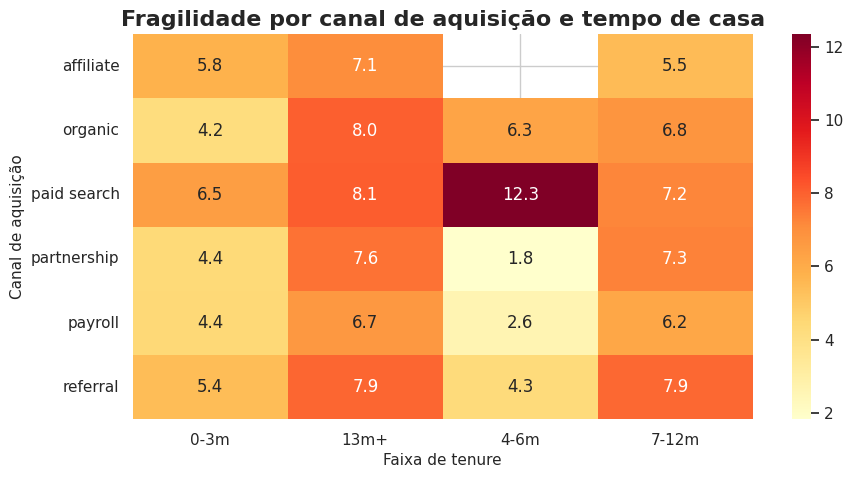

In [14]:
query_cohort_fragility = """
WITH customer_base AS (
    SELECT
        customer_id,
        DATE_TRUNC('quarter', onboarding_date) AS onboarding_quarter,
        LOWER(TRIM(acquisition_channel)) AS acquisition_channel_clean
    FROM dim_customers
),
cohort_perf AS (
    SELECT
        cb.onboarding_quarter,
        cb.acquisition_channel_clean,
        CASE
            WHEN cm.tenure_months <= 3 THEN '0-3m'
            WHEN cm.tenure_months <= 6 THEN '4-6m'
            WHEN cm.tenure_months <= 12 THEN '7-12m'
            ELSE '13m+'
        END AS tenure_bucket,
        COUNT(*) AS observations,
        ROUND(AVG(cm.silent_churn_next_60d), 4) AS silent_churn_rate,
        ROUND(AVG(cm.products_active), 2) AS avg_products_active
    FROM fact_customer_month cm
    INNER JOIN customer_base cb
        ON cm.customer_id = cb.customer_id
    GROUP BY 1, 2, 3
)
SELECT *
FROM cohort_perf
WHERE observations >= 150
ORDER BY onboarding_quarter, acquisition_channel_clean, tenure_bucket
"""

cohort_fragility_df = con.execute(query_cohort_fragility).df()
cohort_fragility_df["silent_churn_rate_pct"] = cohort_fragility_df["silent_churn_rate"] * 100

display(cohort_fragility_df.head(20))

heatmap_df = cohort_fragility_df.pivot_table(
    index="acquisition_channel_clean",
    columns="tenure_bucket",
    values="silent_churn_rate_pct",
    aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Fragilidade por canal de aquisição e tempo de casa")
plt.xlabel("Faixa de tenure")
plt.ylabel("Canal de aquisição")
plt.show()

**Diagnóstico de qualidade e limpeza**

Visão de qualidade — estado bruto


,table_name,rows,columns,missing_pct_avg,duplicate_rows
2,fact_customer_month,38400,27,0.44,0
3,fact_transactions,19381,9,0.00,0
4,fact_support_tickets,14534,8,0.73,184
1,fact_product_holding,12630,8,10.17,0
0,dim_customers,4800,10,0.63,0
5,fact_retention_contacts,3974,9,0.00,59


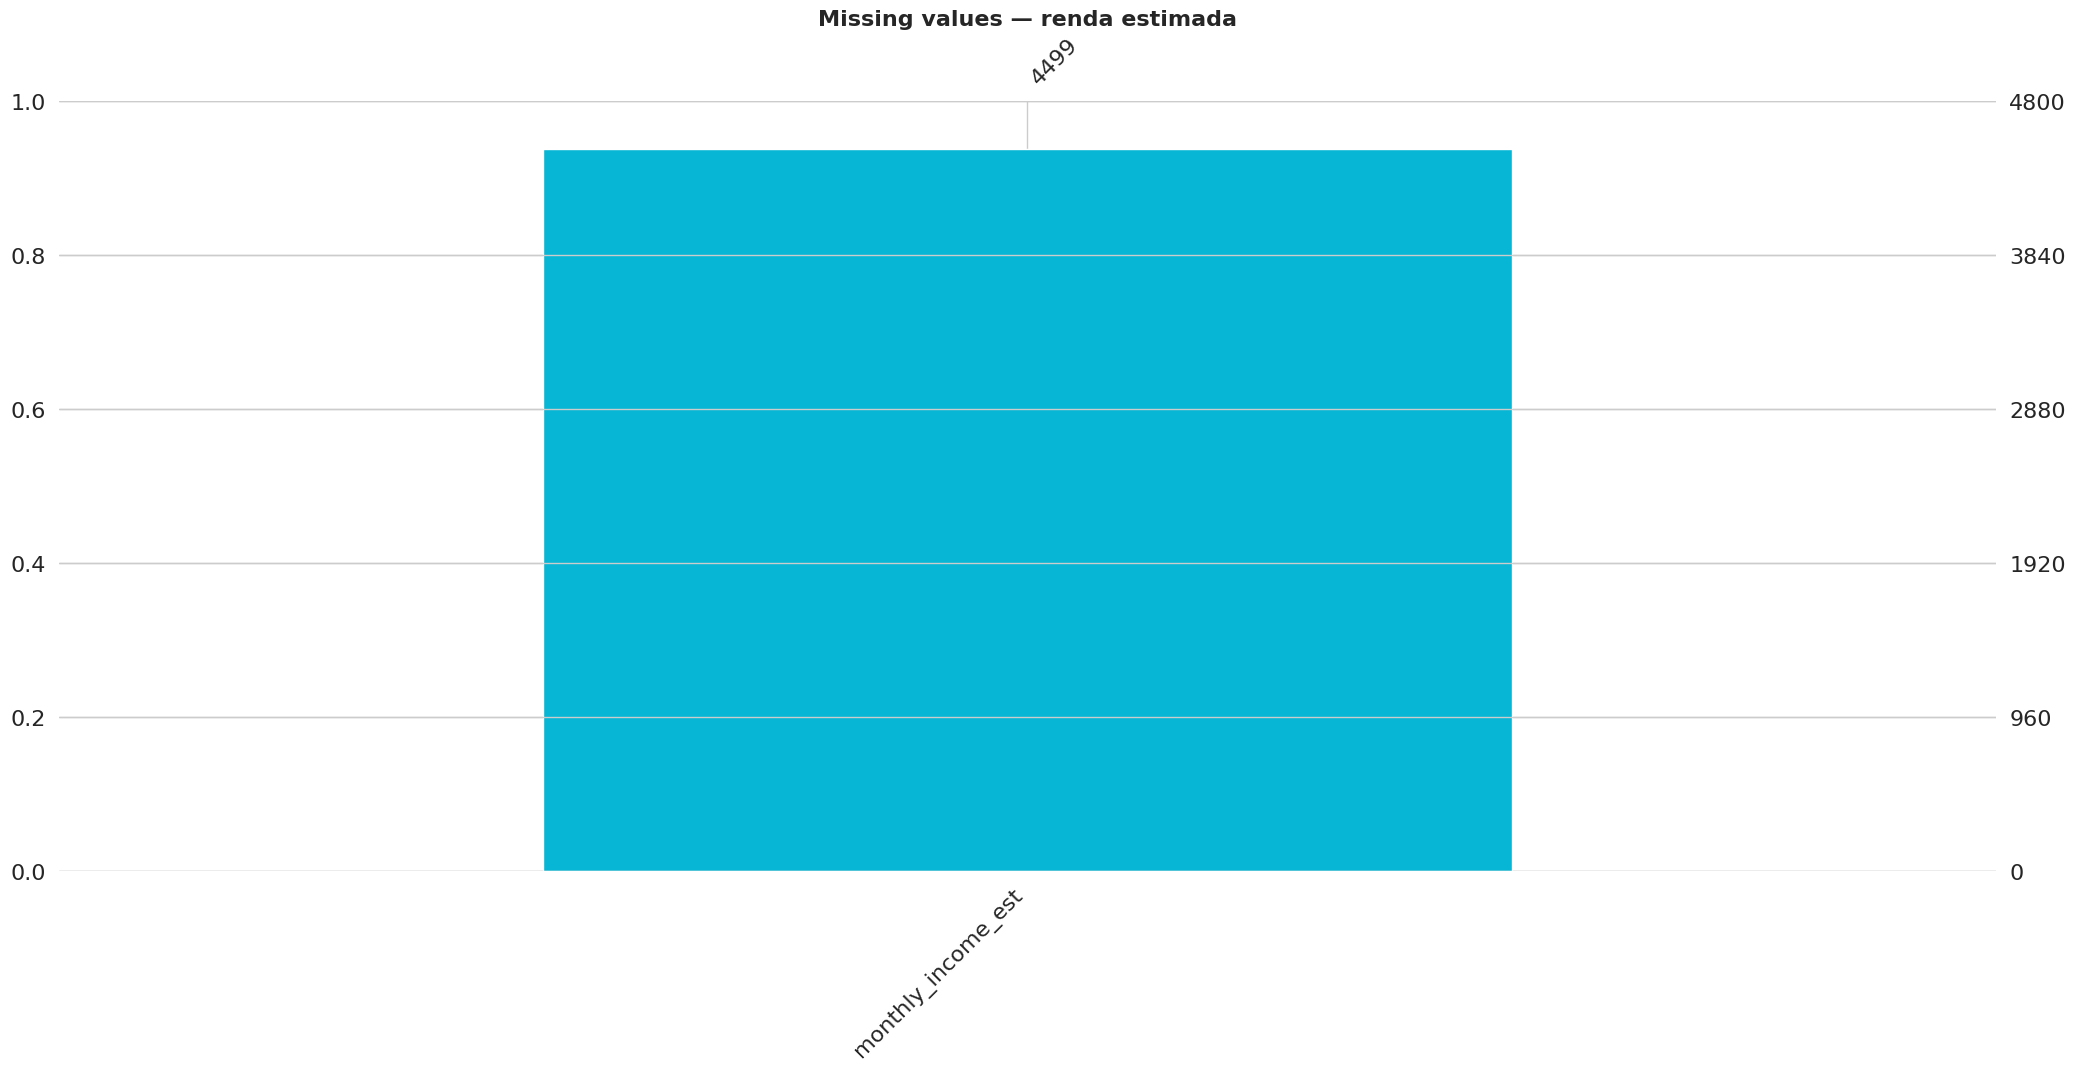

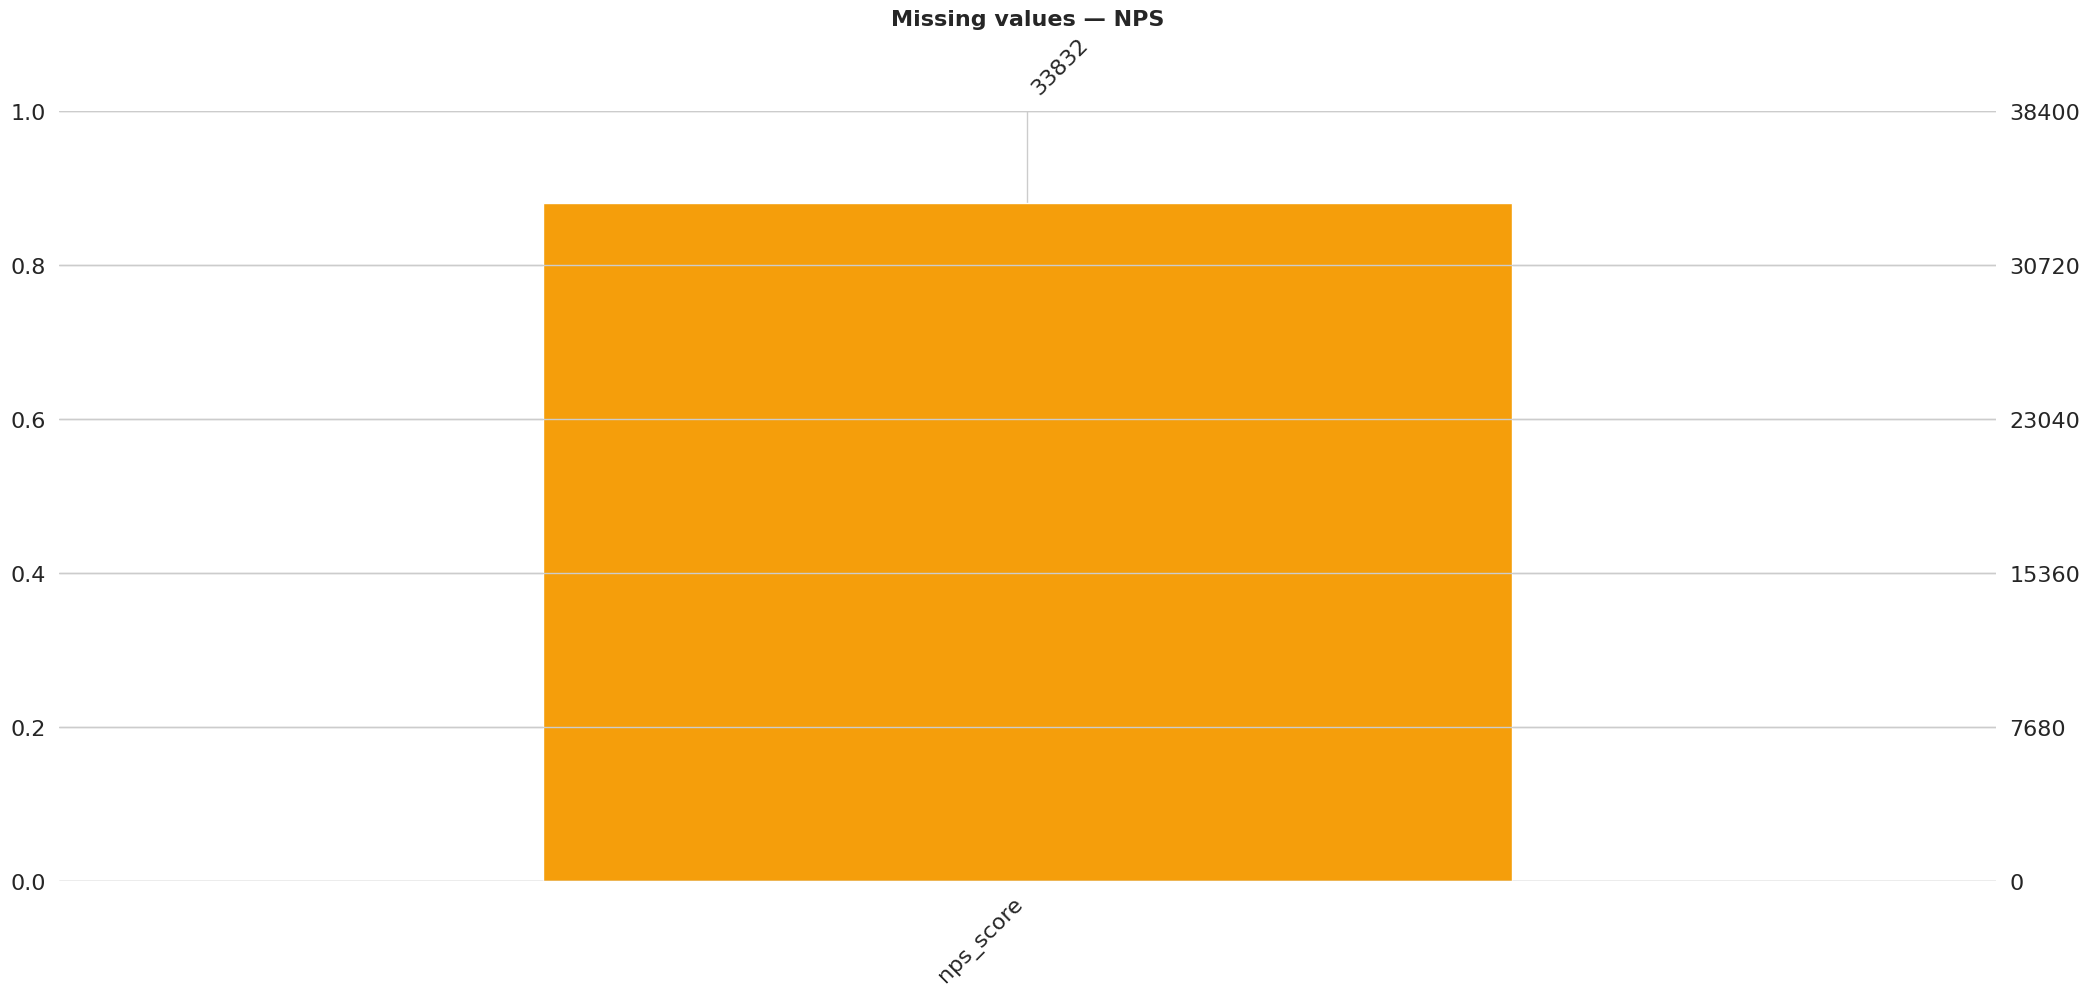

Visão de qualidade — após limpeza


,table_name,rows,columns,missing_pct_avg,duplicate_rows
0,dim_customers_clean,4800,11,0.00,0
1,fact_product_holding_clean,12630,9,9.04,0
2,fact_customer_month_clean,38400,28,0.42,0
3,fact_transactions_clean,19381,9,0.00,0
4,fact_support_tickets_clean,14350,8,0.73,0
5,fact_retention_contacts_clean,3915,9,0.00,0


In [15]:
print("Visão de qualidade — estado bruto")
display(inventory_df)

plt.figure(figsize=(8, 3))
msno.bar(customers_df[["monthly_income_est"]], color=BRAND["cyan"])
plt.title("Missing values — renda estimada")
plt.show()

plt.figure(figsize=(8, 3))
msno.bar(customer_month_df[["nps_score"]], color=BRAND["amber"])
plt.title("Missing values — NPS")
plt.show()

customers_clean = customers_df.copy()
customers_clean["acquisition_channel_clean"] = (
    customers_clean["acquisition_channel"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "paid search": "paid_search",
        "organic": "organic",
        "referral": "referral",
        "payroll": "payroll",
        "affiliate": "affiliate",
        "partnership": "partnership"
    })
)
customers_clean["monthly_income_est"] = customers_clean.groupby("segment")["monthly_income_est"].transform(
    lambda s: s.fillna(s.median())
)

product_holding_clean = product_holding_df.copy()
product_holding_clean["product_name_clean"] = (
    product_holding_clean["product_name"]
    .str.lower()
    .str.strip()
    .str.replace("-", "_", regex=False)
)
product_holding_clean = product_holding_clean.drop_duplicates(
    subset=["customer_id", "product_name_clean", "start_date"]
)

customer_month_clean = customer_month_df.copy()
customer_month_clean["end_balance"] = winsorize_series(customer_month_clean["end_balance"], 0.005, 0.995)
customer_month_clean["nps_score_filled"] = customer_month_clean.groupby("segment")["nps_score"].transform(
    lambda s: s.fillna(s.median())
)

transactions_clean = transactions_df.copy()
transactions_clean["amount"] = winsorize_series(transactions_clean["amount"], 0.005, 0.995)

support_tickets_clean = support_tickets_df.copy()
support_tickets_clean = support_tickets_clean.drop_duplicates(
    subset=["customer_id", "opened_at", "issue_type", "channel"]
)

retention_contacts_clean = retention_contacts_df.copy()
retention_contacts_clean = retention_contacts_clean.drop_duplicates(
    subset=["customer_id", "contact_date", "campaign_name", "channel"]
)

clean_inventory_df = pd.DataFrame([
    table_overview("dim_customers_clean", customers_clean, ["customer_id"]),
    table_overview("fact_product_holding_clean", product_holding_clean, ["customer_id", "product_name_clean", "start_date"]),
    table_overview("fact_customer_month_clean", customer_month_clean, ["customer_id", "snapshot_month"]),
    table_overview("fact_transactions_clean", transactions_clean, ["transaction_id"]),
    table_overview("fact_support_tickets_clean", support_tickets_clean, ["customer_id", "opened_at", "issue_type", "channel"]),
    table_overview("fact_retention_contacts_clean", retention_contacts_clean, ["customer_id", "contact_date", "campaign_name", "channel"]),
])

print("Visão de qualidade — após limpeza")
display(clean_inventory_df)

**Feature engineering**

In [16]:
ticket_monthly_df = (
    support_tickets_clean
    .assign(snapshot_month=support_tickets_clean["opened_at"].values.astype("datetime64[M]"))
    .groupby(["customer_id", "snapshot_month"])
    .agg(
        tickets_logged=("ticket_id", "count"),
        avg_resolution_hours=("resolution_hours", "mean"),
        escalated_tickets=("resolution_status", lambda s: (s == "escalated").sum()),
        open_tickets=("resolution_status", lambda s: (s == "open").sum())
    )
    .reset_index()
)

contact_monthly_df = (
    retention_contacts_clean
    .assign(snapshot_month=retention_contacts_clean["contact_date"].values.astype("datetime64[M]"))
    .groupby(["customer_id", "snapshot_month"])
    .agg(
        contacts_sent=("contact_id", "count"),
        contacts_opened=("opened_flag", "sum"),
        contacts_clicked=("clicked_flag", "sum"),
        contacts_converted=("converted_flag", "sum")
    )
    .reset_index()
)

feature_df = (
    customer_month_clean
    .merge(
        customers_clean[["customer_id", "monthly_income_est", "acquisition_channel_clean"]],
        on="customer_id",
        how="left",
        suffixes=("", "_customer")
    )
    .merge(ticket_monthly_df, on=["customer_id", "snapshot_month"], how="left")
    .merge(contact_monthly_df, on=["customer_id", "snapshot_month"], how="left")
    .sort_values(["customer_id", "snapshot_month"])
)

for col in [
    "tickets_logged", "avg_resolution_hours", "escalated_tickets", "open_tickets",
    "contacts_sent", "contacts_opened", "contacts_clicked", "contacts_converted"
]:
    feature_df[col] = feature_df[col].fillna(0)

feature_df["balance_delta_pct"] = (
    feature_df.groupby("customer_id")["end_balance"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
)

feature_df["engagement_delta_pct"] = (
    feature_df.groupby("customer_id")["app_sessions"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0)
)

feature_df["rolling_ticket_3m"] = (
    feature_df.groupby("customer_id")["tickets_logged"]
    .rolling(3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

feature_df["contact_pressure_90d"] = (
    feature_df.groupby("customer_id")["contacts_sent"]
    .rolling(3, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
)

feature_df["revenue_per_product"] = feature_df["gross_revenue"] / feature_df["products_active"].replace(0, 1)
feature_df["high_support_friction"] = ((feature_df["avg_resolution_hours"] > 24) | (feature_df["escalated_tickets"] > 0)).astype(int)

feature_df["estimated_annual_value"] = (
    feature_df["gross_revenue"] * 12
    + np.maximum(feature_df["end_balance"], 0) * 0.018
    + feature_df["card_spend"] * 0.005 * 12
).round(2)

feature_df.head()

,customer_id,snapshot_month,age,segment,state,city_tier,acquisition_channel,salary_portability_flag,tenure_months,products_active,login_days,app_sessions,active_days,days_since_last_txn,pix_volume,card_spend,avg_balance,end_balance,card_decline_rate,loan_installment_delay_days,support_tickets_opened,nps_score,fee_revenue,interchange_revenue,interest_revenue,gross_revenue,silent_churn_next_60d,nps_score_filled,monthly_income_est,acquisition_channel_clean,tickets_logged,avg_resolution_hours,escalated_tickets,open_tickets,contacts_sent,contacts_opened,contacts_clicked,contacts_converted,balance_delta_pct,engagement_delta_pct,rolling_ticket_3m,contact_pressure_90d,revenue_per_product,high_support_friction,estimated_annual_value
0,C000001,2025-01-01,40,Mass,RJ,Interior,Paid Search,0,1,1,7,13,6,18,411.44,39.49,"4,136.83","3,513.24",0.00,0,0,8.00,7.00,0.49,0.00,7.49,0,8.00,"2,739.85",paid_search,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.49,0,155.49
1,C000001,2025-02-01,40,Mass,RJ,Interior,Paid Search,0,1,1,11,16,9,7,"1,510.79",511.64,"1,806.70","1,472.39",0.05,0,1,8.00,7.00,6.40,0.00,13.40,0,8.00,"2,739.85",paid_search,1.00,7.60,0.00,0.00,0.00,0.00,0.00,0.00,-0.58,0.23,1.00,0.00,13.40,0,218.00
2,C000001,2025-03-01,40,Mass,RJ,Interior,Paid Search,0,2,1,6,8,6,6,706.74,627.12,"1,266.88","1,212.11",0.06,0,0,9.00,7.00,7.84,0.00,14.84,0,9.00,"2,739.85",paid_search,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,-0.18,-0.50,1.00,1.00,14.84,0,237.53
3,C000001,2025-04-01,40,Mass,RJ,Interior,Paid Search,0,3,2,12,24,10,4,"1,546.57","1,276.19","2,871.64","2,666.31",0.16,0,0,9.00,7.00,15.95,0.00,22.95,1,9.00,"2,739.85",paid_search,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.20,2.00,1.00,2.00,11.47,0,399.96
4,C000001,2025-05-01,40,Mass,RJ,Interior,Paid Search,0,4,2,3,0,3,30,781.93,692.51,"2,090.82","1,834.44",0.09,0,0,NaN,12.00,8.66,0.00,20.66,0,7.00,"2,739.85",paid_search,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.31,-1.00,0.00,2.00,10.33,0,322.49


**Deep dive visual: profundidade de produto x risco**

In [17]:
risk_by_portfolio_df = (
    feature_df
    .groupby(["segment", "products_active"])
    .agg(
        silent_churn_rate=("silent_churn_next_60d", "mean"),
        avg_annual_value=("estimated_annual_value", "mean"),
        obs=("customer_id", "count")
    )
    .reset_index()
)

risk_by_portfolio_df["silent_churn_rate_pct"] = risk_by_portfolio_df["silent_churn_rate"] * 100

fig = px.line(
    risk_by_portfolio_df,
    x="products_active",
    y="silent_churn_rate_pct",
    color="segment",
    markers=True,
    color_discrete_map={"Mass": BRAND["rose"], "Emerging": BRAND["amber"], "Affluent": BRAND["emerald"]}
)
fig = plotly_style(fig, "Profundidade de produto vs. risco de silent churn")
fig.update_xaxes(title="Produtos ativos")
fig.update_yaxes(title="Silent churn (%)")
fig.show()

**Deep dive visual + estatística aplicada**

In [18]:
support_profile_df = (
    feature_df
    .groupby(["high_support_friction", "segment"])
    .agg(
        churn_rate=("silent_churn_next_60d", "mean"),
        avg_balance=("end_balance", "mean"),
        customers=("customer_id", "count")
    )
    .reset_index()
)

support_profile_df["friction_label"] = support_profile_df["high_support_friction"].map({0: "Baixa fricção", 1: "Alta fricção"})
support_profile_df["churn_rate_pct"] = support_profile_df["churn_rate"] * 100

fig = px.bar(
    support_profile_df,
    x="segment",
    y="churn_rate_pct",
    color="friction_label",
    barmode="group",
    color_discrete_map={"Baixa fricção": BRAND["emerald"], "Alta fricção": BRAND["rose"]}
)
fig = plotly_style(fig, "Risco de evasão por segmento e fricção de suporte")
fig.update_yaxes(title="Silent churn (%)")
fig.show()

churned = feature_df[feature_df["silent_churn_next_60d"] == 1]
stable = feature_df[feature_df["silent_churn_next_60d"] == 0]

mannwhitney_login = stats.mannwhitneyu(churned["login_days"], stable["login_days"], alternative="two-sided")
mannwhitney_days = stats.mannwhitneyu(churned["days_since_last_txn"], stable["days_since_last_txn"], alternative="two-sided")

chi2, p_value, _, _ = stats.chi2_contingency(
    pd.crosstab(feature_df["high_support_friction"], feature_df["silent_churn_next_60d"])
)

tests_df = pd.DataFrame([
    ["Login days — churned vs stable", mannwhitney_login.statistic, mannwhitney_login.pvalue],
    ["Days since last txn — churned vs stable", mannwhitney_days.statistic, mannwhitney_days.pvalue],
    ["High support friction vs churn (chi-square)", chi2, p_value],
], columns=["test_name", "statistic", "p_value"])

display(tests_df)

,test_name,statistic,p_value
0,Login days — churned vs stable,"19,442,129.50",0.00
1,Days since last txn — churned vs stable,"76,107,404.50",0.00
2,High support friction vs churn (chi-square),308.70,0.00


**Score preditivo leve com validação temporal**

In [19]:
train_df = feature_df[feature_df["snapshot_month"] < "2025-07-01"].copy()
test_df = feature_df[feature_df["snapshot_month"] >= "2025-07-01"].copy()

numeric_features = [
    "age", "monthly_income_est", "tenure_months", "products_active", "login_days", "app_sessions",
    "days_since_last_txn", "avg_balance", "end_balance", "pix_volume", "card_spend",
    "card_decline_rate", "loan_installment_delay_days", "tickets_logged", "avg_resolution_hours",
    "rolling_ticket_3m", "balance_delta_pct", "engagement_delta_pct", "contact_pressure_90d",
    "gross_revenue", "nps_score_filled"
]

categorical_features = ["segment", "city_tier", "acquisition_channel_clean"]

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["silent_churn_next_60d"]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df["silent_churn_next_60d"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

model.fit(X_train, y_train)

test_scored_df = test_df.copy()
test_scored_df["predicted_churn_prob"] = model.predict_proba(X_test)[:, 1]

metrics_df = pd.DataFrame({
    "metric": ["ROC AUC", "Average Precision", "Base Rate"],
    "value": [
        roc_auc_score(y_test, test_scored_df["predicted_churn_prob"]),
        average_precision_score(y_test, test_scored_df["predicted_churn_prob"]),
        y_test.mean()
    ]
})

display(metrics_df)

precision, recall, _ = precision_recall_curve(y_test, test_scored_df["predicted_churn_prob"])

fig = go.Figure()
fig.add_trace(go.Scatter(x=recall, y=precision, mode="lines", line=dict(color=BRAND["violet"], width=3)))
fig = plotly_style(fig, "Curva Precision-Recall — validação temporal", height=460)
fig.update_xaxes(title="Recall")
fig.update_yaxes(title="Precision")
fig.show()

,metric,value
0,ROC AUC,0.89
1,Average Precision,0.57
2,Base Rate,0.16


**Drivers do score e lift por decil**

In [20]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=SEED,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(12))

fig = px.bar(
    importance_df.head(12).sort_values("importance_mean"),
    x="importance_mean",
    y="feature",
    orientation="h",
    color="importance_mean",
    color_continuous_scale=["#BFDBFE", BRAND["cyan"], BRAND["violet"]]
)
fig = plotly_style(fig, "Drivers mais relevantes do score", height=520)
fig.update_xaxes(title="Permutation importance (ROC AUC)")
fig.update_yaxes(title="")
fig.show()

test_scored_df["risk_decile"] = pd.qcut(
    test_scored_df["predicted_churn_prob"].rank(method="first"),
    10,
    labels=False
) + 1

baseline_rate = test_scored_df["silent_churn_next_60d"].mean()

decile_perf_df = (
    test_scored_df
    .groupby("risk_decile")
    .agg(
        customers=("customer_id", "count"),
        churn_rate=("silent_churn_next_60d", "mean"),
        captured_churn=("silent_churn_next_60d", "sum")
    )
    .reset_index()
    .sort_values("risk_decile", ascending=False)
)

decile_perf_df["lift_vs_baseline"] = decile_perf_df["churn_rate"] / baseline_rate
decile_perf_df["capture_share"] = decile_perf_df["captured_churn"] / test_scored_df["silent_churn_next_60d"].sum()

display(decile_perf_df)

fig = px.line(
    decile_perf_df,
    x="risk_decile",
    y="lift_vs_baseline",
    markers=True
)
fig = plotly_style(fig, "Lift por decil de risco", height=460)
fig.update_xaxes(title="Decil de risco (10 = maior risco)")
fig.update_yaxes(title="Lift vs baseline")
fig.show()

,feature,importance_mean
18,contact_pressure_90d,0.15
10,card_spend,0.14
19,gross_revenue,0.12
6,days_since_last_txn,0.04
11,card_decline_rate,0.04
13,tickets_logged,0.01
8,end_balance,0.01
21,segment,0.00
12,loan_installment_delay_days,0.00
15,rolling_ticket_3m,0.00


,risk_decile,customers,churn_rate,captured_churn,lift_vs_baseline,capture_share
9,10,960,0.61,587,3.90,0.39
8,9,960,0.46,442,2.94,0.29
7,8,960,0.23,219,1.46,0.15
6,7,960,0.13,121,0.80,0.08
5,6,960,0.08,79,0.53,0.05
4,5,960,0.03,27,0.18,0.02
3,4,960,0.01,14,0.09,0.01
2,3,960,0.00,4,0.03,0.00
1,2,960,0.01,6,0.04,0.00
0,1,960,0.01,5,0.03,0.00


**Matriz de priorização: risco x valor**

In [21]:
latest_month = feature_df["snapshot_month"].max()
latest_scoring_df = feature_df[feature_df["snapshot_month"] == latest_month].copy()

latest_scoring_df["predicted_churn_prob"] = model.predict_proba(
    latest_scoring_df[numeric_features + categorical_features]
)[:, 1]

latest_scoring_df["expected_value_at_risk"] = (
    latest_scoring_df["predicted_churn_prob"] * latest_scoring_df["estimated_annual_value"]
)

risk_hi = latest_scoring_df["predicted_churn_prob"].quantile(0.75)
risk_md = latest_scoring_df["predicted_churn_prob"].quantile(0.50)
value_hi = latest_scoring_df["estimated_annual_value"].quantile(0.75)

def action_segment(row):
    if row["predicted_churn_prob"] >= risk_hi and row["estimated_annual_value"] >= value_hi:
        return "Rescue Now"
    elif row["estimated_annual_value"] >= value_hi and row["predicted_churn_prob"] >= risk_md:
        return "Protect"
    elif row["predicted_churn_prob"] >= risk_hi:
        return "Nurture"
    return "Monitor"

latest_scoring_df["action_segment"] = latest_scoring_df.apply(action_segment, axis=1)

fig = px.scatter(
    latest_scoring_df,
    x="predicted_churn_prob",
    y="estimated_annual_value",
    size="expected_value_at_risk",
    color="action_segment",
    hover_data=["customer_id", "segment", "products_active", "login_days", "days_since_last_txn"],
    color_discrete_map={
        "Rescue Now": BRAND["rose"],
        "Protect": BRAND["amber"],
        "Nurture": BRAND["violet"],
        "Monitor": BRAND["slate"]
    }
)
fig = plotly_style(fig, "Matriz de priorização — risco previsto x valor anual estimado", height=620)
fig.update_xaxes(title="Probabilidade prevista de silent churn")
fig.update_yaxes(title="Valor anual estimado")
fig.show()

rescue_now_df = (
    latest_scoring_df[latest_scoring_df["action_segment"] == "Rescue Now"]
    .sort_values("expected_value_at_risk", ascending=False)
    [["customer_id", "segment", "estimated_annual_value", "predicted_churn_prob", "expected_value_at_risk", "products_active", "days_since_last_txn"]]
    .head(15)
)

display(rescue_now_df)

,customer_id,segment,estimated_annual_value,predicted_churn_prob,expected_value_at_risk,products_active,days_since_last_txn
34799,C004350,Emerging,"4,056.73",0.99,"4,012.05",2,11
5951,C000744,Affluent,"3,063.31",0.95,"2,911.78",3,25
34263,C004283,Affluent,"2,628.44",0.96,"2,515.81",4,37
25615,C003202,Affluent,"2,455.91",0.97,"2,370.37",4,26
6319,C000790,Affluent,"2,524.33",0.93,"2,341.98",4,32
8591,C001074,Affluent,"2,246.36",1.00,"2,235.42",3,44
22135,C002767,Affluent,"2,218.53",0.99,"2,205.44",3,36
6183,C000773,Affluent,"2,166.93",0.98,"2,116.07",3,43
5591,C000699,Affluent,"2,060.94",0.98,"2,017.06",5,32
7287,C000911,Affluent,"2,175.73",0.93,"2,014.37",4,36


**Criação das tabelas e carga**

In [24]:
con = duckdb.connect()

# Registrar os DataFrames no DuckDB
con.register("dim_customers_df", customers_df)
con.register("fact_product_holding_df", product_holding_df)
con.register("fact_customer_month_df", customer_month_df)
con.register("fact_transactions_df", transactions_df)
con.register("fact_support_tickets_df", support_tickets_df)
con.register("fact_retention_contacts_df", retention_contacts_df)

# Criar as tabelas físicas dentro do DuckDB
con.execute("""
CREATE OR REPLACE TABLE dim_customers AS
SELECT * FROM dim_customers_df
""")

con.execute("""
CREATE OR REPLACE TABLE fact_product_holding AS
SELECT * FROM fact_product_holding_df
""")

con.execute("""
CREATE OR REPLACE TABLE fact_customer_month AS
SELECT * FROM fact_customer_month_df
""")

con.execute("""
CREATE OR REPLACE TABLE fact_transactions AS
SELECT * FROM fact_transactions_df
""")

con.execute("""
CREATE OR REPLACE TABLE fact_support_tickets AS
SELECT * FROM fact_support_tickets_df
""")

con.execute("""
CREATE OR REPLACE TABLE fact_retention_contacts AS
SELECT * FROM fact_retention_contacts_df
""")

# Conferir se as tabelas foram criadas
tables_df = con.execute("SHOW TABLES").df()
display(tables_df)

,name
0,dim_customers
1,dim_customers_df
2,fact_customer_month
3,fact_customer_month_df
4,fact_product_holding
5,fact_product_holding_df
6,fact_retention_contacts
7,fact_retention_contacts_df
8,fact_support_tickets
9,fact_support_tickets_df


**KPIs mensais por segmento**

In [25]:
query_monthly_kpis = """
WITH monthly_kpis AS (
    SELECT
        snapshot_month,
        segment,
        COUNT(DISTINCT customer_id) AS active_customers,
        ROUND(SUM(gross_revenue), 2) AS gross_revenue,
        ROUND(AVG(end_balance), 2) AS avg_end_balance,
        ROUND(AVG(app_sessions), 1) AS avg_app_sessions,
        ROUND(AVG(silent_churn_next_60d), 4) AS silent_churn_rate,
        ROUND(SUM(gross_revenue * silent_churn_next_60d), 2) AS monthly_revenue_at_risk
    FROM fact_customer_month
    GROUP BY 1, 2
)
SELECT *
FROM monthly_kpis
ORDER BY snapshot_month, segment
"""

monthly_kpis_df = con.execute(query_monthly_kpis).df()
display(monthly_kpis_df)

,snapshot_month,segment,active_customers,gross_revenue,avg_end_balance,avg_app_sessions,silent_churn_rate,monthly_revenue_at_risk
0,2025-01-01,Affluent,552,"30,807.77","66,084.10",32.80,0.01,564.15
1,2025-01-01,Emerging,1179,"23,054.00","14,072.24",28.20,0.02,411.39
2,2025-01-01,Mass,3069,"39,642.96","3,531.03",23.20,0.03,"1,546.90"
3,2025-02-01,Affluent,552,"30,940.43","65,834.71",32.10,0.02,794.85
4,2025-02-01,Emerging,1179,"24,379.58","14,160.31",28.30,0.02,456.28
5,2025-02-01,Mass,3069,"40,308.95","3,575.75",23.10,0.03,"1,369.39"
6,2025-03-01,Affluent,552,"34,644.02","72,274.77",32.70,0.02,"1,128.19"
7,2025-03-01,Emerging,1179,"25,304.33","14,137.03",28.70,0.02,387.99
8,2025-03-01,Mass,3069,"40,756.22","3,688.17",23.20,0.03,"1,520.66"
9,2025-04-01,Affluent,552,"35,620.94","68,421.02",32.40,0.01,128.60


In [26]:
query_support_friction = """
WITH ticket_monthly AS (
    SELECT
        customer_id,
        DATE_TRUNC('month', opened_at) AS snapshot_month,
        issue_type,
        COUNT(*) AS tickets,
        AVG(COALESCE(resolution_hours, 72)) AS avg_resolution_hours
    FROM fact_support_tickets
    GROUP BY 1, 2, 3
),
joined AS (
    SELECT
        cm.customer_id,
        cm.snapshot_month,
        cm.segment,
        cm.silent_churn_next_60d,
        COALESCE(tm.issue_type, 'no_ticket') AS issue_type,
        CASE
            WHEN tm.avg_resolution_hours IS NULL THEN 'no_ticket'
            WHEN tm.avg_resolution_hours <= 6 THEN 'resolved_<6h'
            WHEN tm.avg_resolution_hours <= 24 THEN 'resolved_6_24h'
            WHEN tm.avg_resolution_hours <= 72 THEN 'resolved_24_72h'
            ELSE 'resolved_>72h_or_open'
        END AS sla_bucket
    FROM fact_customer_month cm
    LEFT JOIN ticket_monthly tm
        ON cm.customer_id = tm.customer_id
       AND cm.snapshot_month = tm.snapshot_month
)
SELECT
    issue_type,
    sla_bucket,
    COUNT(*) AS observations,
    ROUND(AVG(silent_churn_next_60d), 4) AS churn_rate
FROM joined
GROUP BY 1, 2
HAVING COUNT(*) >= 80
ORDER BY churn_rate DESC, observations DESC
"""

support_friction_df = con.execute(query_support_friction).df()
display(support_friction_df)

,issue_type,sla_bucket,observations,churn_rate
0,failed_transfer,resolved_24_72h,395,0.22
1,card_decline,resolved_6_24h,1588,0.22
2,loan_renegotiation,resolved_24_72h,441,0.20
3,failed_transfer,resolved_6_24h,1263,0.19
4,card_decline,resolved_<6h,966,0.19
5,fraud_alert,resolved_6_24h,1068,0.19
6,fraud_alert,resolved_<6h,274,0.19
7,billing_question,resolved_<6h,860,0.18
8,card_decline,resolved_24_72h,483,0.18
9,billing_question,resolved_24_72h,335,0.17


In [27]:
query_latest_ranking = """
WITH with_lag AS (
    SELECT
        customer_id,
        snapshot_month,
        segment,
        end_balance,
        app_sessions,
        gross_revenue,
        silent_churn_next_60d,
        LAG(end_balance) OVER (PARTITION BY customer_id ORDER BY snapshot_month) AS prev_end_balance,
        LAG(app_sessions) OVER (PARTITION BY customer_id ORDER BY snapshot_month) AS prev_app_sessions
    FROM fact_customer_month
),
latest_scored AS (
    SELECT
        customer_id,
        snapshot_month,
        segment,
        end_balance,
        app_sessions,
        gross_revenue,
        silent_churn_next_60d,
        ROUND(COALESCE((end_balance - prev_end_balance) / NULLIF(prev_end_balance, 0), 0), 4) AS balance_mom_pct,
        ROUND(COALESCE((app_sessions - prev_app_sessions) / NULLIF(prev_app_sessions, 0), 0), 4) AS sessions_mom_pct,
        ROUND((gross_revenue * 12 + GREATEST(end_balance, 0) * 0.015) * silent_churn_next_60d, 2) AS expected_value_at_risk
    FROM with_lag
    WHERE snapshot_month = (SELECT MAX(snapshot_month) FROM fact_customer_month)
),
ranked AS (
    SELECT
        *,
        DENSE_RANK() OVER (PARTITION BY segment ORDER BY expected_value_at_risk DESC) AS segment_priority_rank
    FROM latest_scored
)
SELECT *
FROM ranked
WHERE segment_priority_rank <= 10
ORDER BY expected_value_at_risk DESC
"""

latest_ranking_df = con.execute(query_latest_ranking).df()
display(latest_ranking_df)

,customer_id,snapshot_month,segment,end_balance,app_sessions,gross_revenue,silent_churn_next_60d,balance_mom_pct,sessions_mom_pct,expected_value_at_risk,segment_priority_rank
0,C004508,2025-08-01,Affluent,"70,589.00",24,130.39,1,0.76,0.04,"2,623.52",1
1,C001851,2025-08-01,Emerging,"76,291.04",35,116.75,1,2.20,1.33,"2,545.37",1
2,C000744,2025-08-01,Affluent,"29,195.53",26,151.06,1,-0.01,0.37,"2,250.65",2
3,C004364,2025-08-01,Affluent,"69,503.65",36,96.60,1,1.82,-0.27,"2,201.75",3
4,C003041,2025-08-01,Affluent,"68,684.48",17,88.65,1,-0.42,-0.06,"2,094.07",4
5,C004756,2025-08-01,Affluent,"97,217.57",34,51.16,1,0.43,-0.33,"2,072.18",5
6,C003899,2025-08-01,Affluent,"55,330.95",10,92.40,1,-0.12,0.43,"1,938.76",6
7,C004023,2025-08-01,Affluent,"21,269.51",17,124.88,1,-0.84,-0.15,"1,817.60",7
8,C000911,2025-08-01,Affluent,"55,922.88",11,78.22,1,0.09,0.38,"1,777.48",8
9,C002767,2025-08-01,Affluent,"42,181.95",9,90.86,1,0.14,0.12,"1,723.05",9


In [28]:
query_cohort_fragility = """
WITH customer_base AS (
    SELECT
        customer_id,
        DATE_TRUNC('quarter', onboarding_date) AS onboarding_quarter,
        LOWER(TRIM(acquisition_channel)) AS acquisition_channel_clean
    FROM dim_customers
),
cohort_perf AS (
    SELECT
        cb.onboarding_quarter,
        cb.acquisition_channel_clean,
        CASE
            WHEN cm.tenure_months <= 3 THEN '0-3m'
            WHEN cm.tenure_months <= 6 THEN '4-6m'
            WHEN cm.tenure_months <= 12 THEN '7-12m'
            ELSE '13m+'
        END AS tenure_bucket,
        COUNT(*) AS observations,
        ROUND(AVG(cm.silent_churn_next_60d), 4) AS silent_churn_rate,
        ROUND(AVG(cm.products_active), 2) AS avg_products_active
    FROM fact_customer_month cm
    INNER JOIN customer_base cb
        ON cm.customer_id = cb.customer_id
    GROUP BY 1, 2, 3
)
SELECT *
FROM cohort_perf
WHERE observations >= 150
ORDER BY onboarding_quarter, acquisition_channel_clean, tenure_bucket
"""

cohort_fragility_df = con.execute(query_cohort_fragility).df()
display(cohort_fragility_df)

,onboarding_quarter,acquisition_channel_clean,tenure_bucket,observations,silent_churn_rate,avg_products_active
0,2022-01-01,affiliate,13m+,416,0.06,2.56
1,2022-01-01,organic,13m+,568,0.07,2.44
2,2022-01-01,paid search,13m+,424,0.05,2.64
3,2022-01-01,partnership,13m+,464,0.08,2.45
4,2022-01-01,payroll,13m+,408,0.03,2.45
...,...,...,...,...,...,...
90,2025-04-01,organic,0-3m,740,0.06,1.17
91,2025-04-01,paid search,0-3m,566,0.09,1.18
92,2025-04-01,partnership,0-3m,383,0.06,1.16
93,2025-04-01,payroll,0-3m,358,0.06,1.20
